## CLUSTERING ANALYSIS

### Task1

In [2]:
##importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

In [3]:
df = pd.read_excel("EastWestAirlines.xlsx", sheet_name=1)
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [5]:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [6]:
df.shape

(3999, 12)

In [7]:
df.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [9]:
df = df.drop_duplicates()

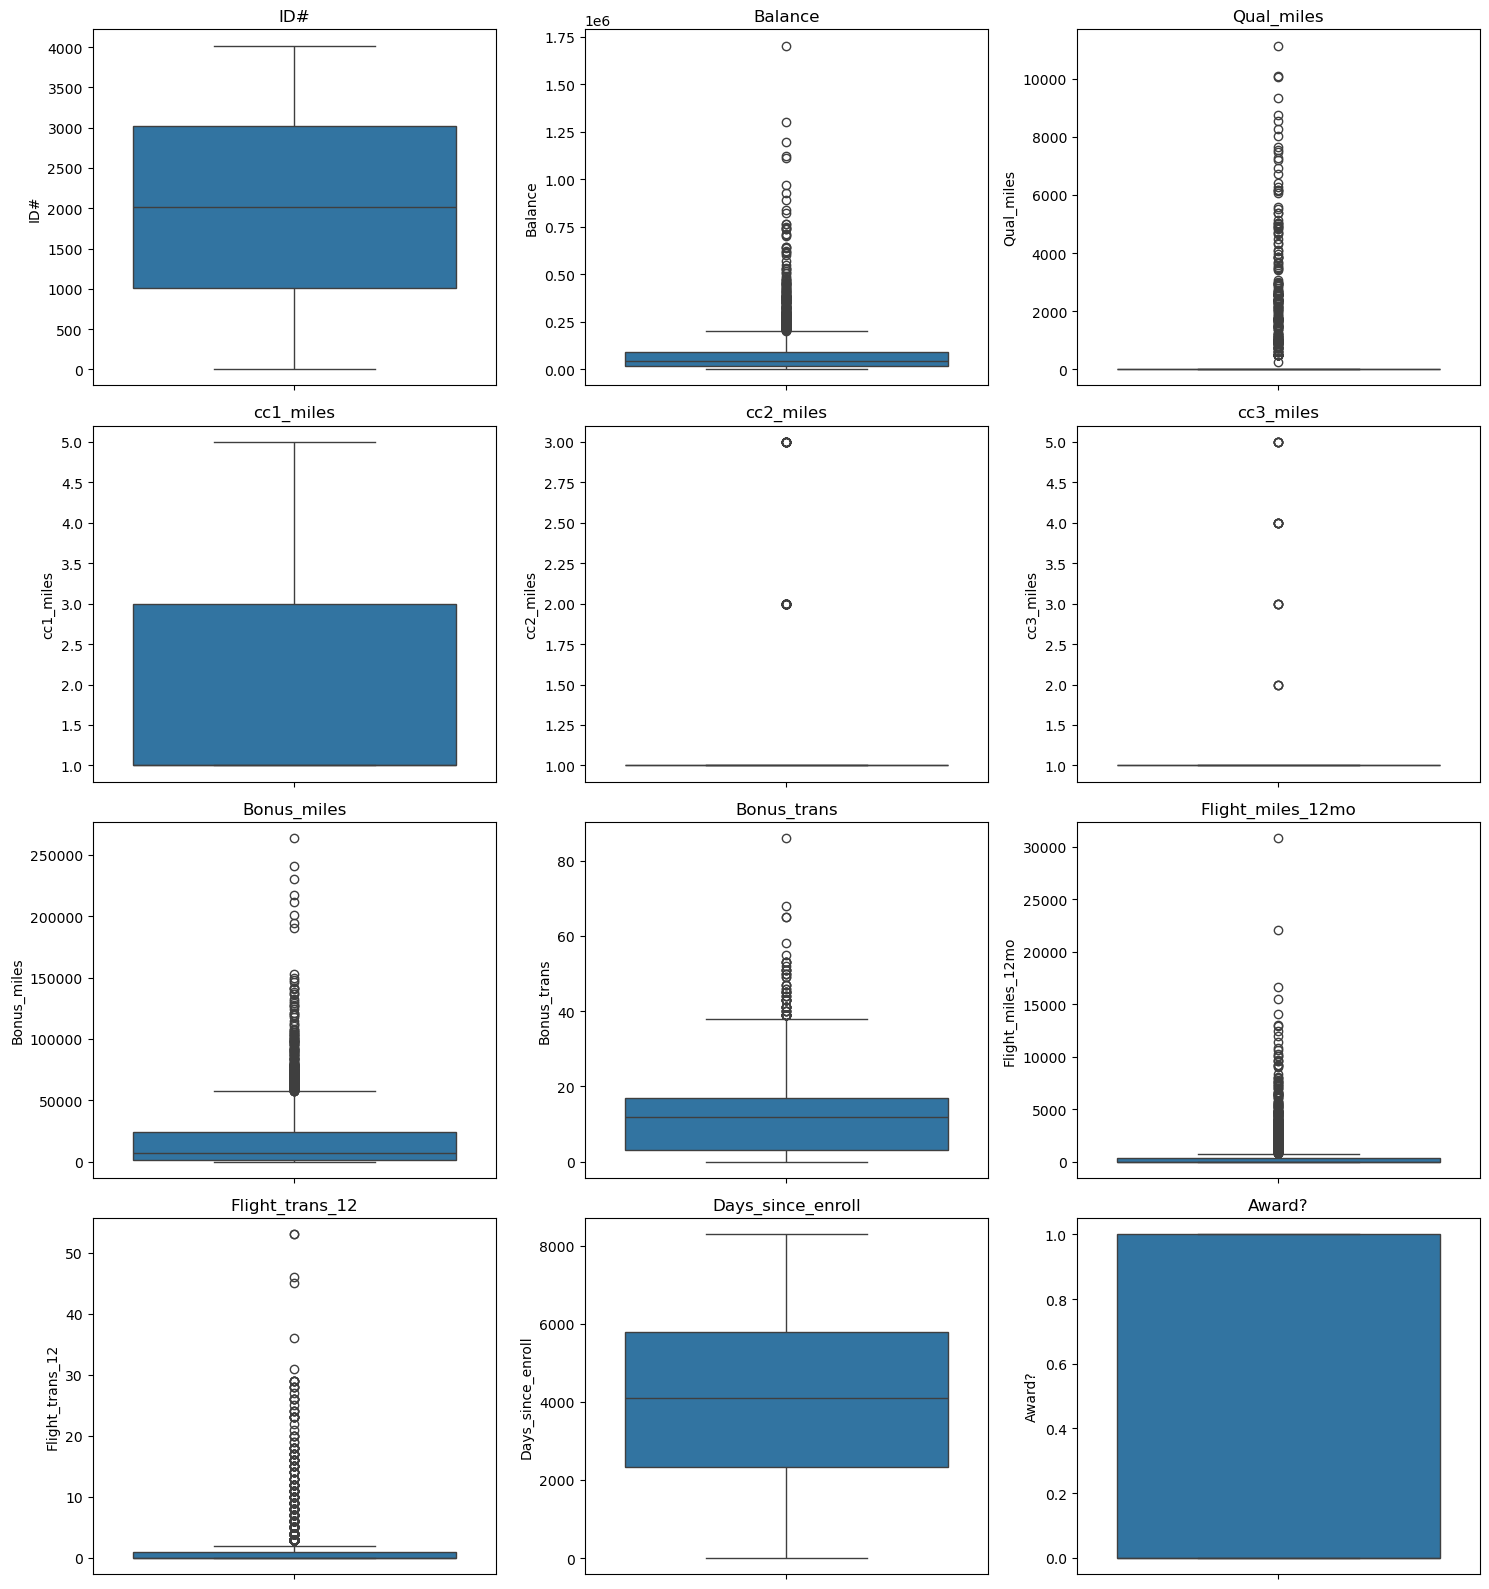

In [10]:
numeric_cols = df.select_dtypes(include=np.number).columns
rows = (len(numeric_cols) + 2) // 3
plt.figure(figsize=(15, rows * 4))
for i, col in enumerate(numeric_cols):
    plt.subplot(rows, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

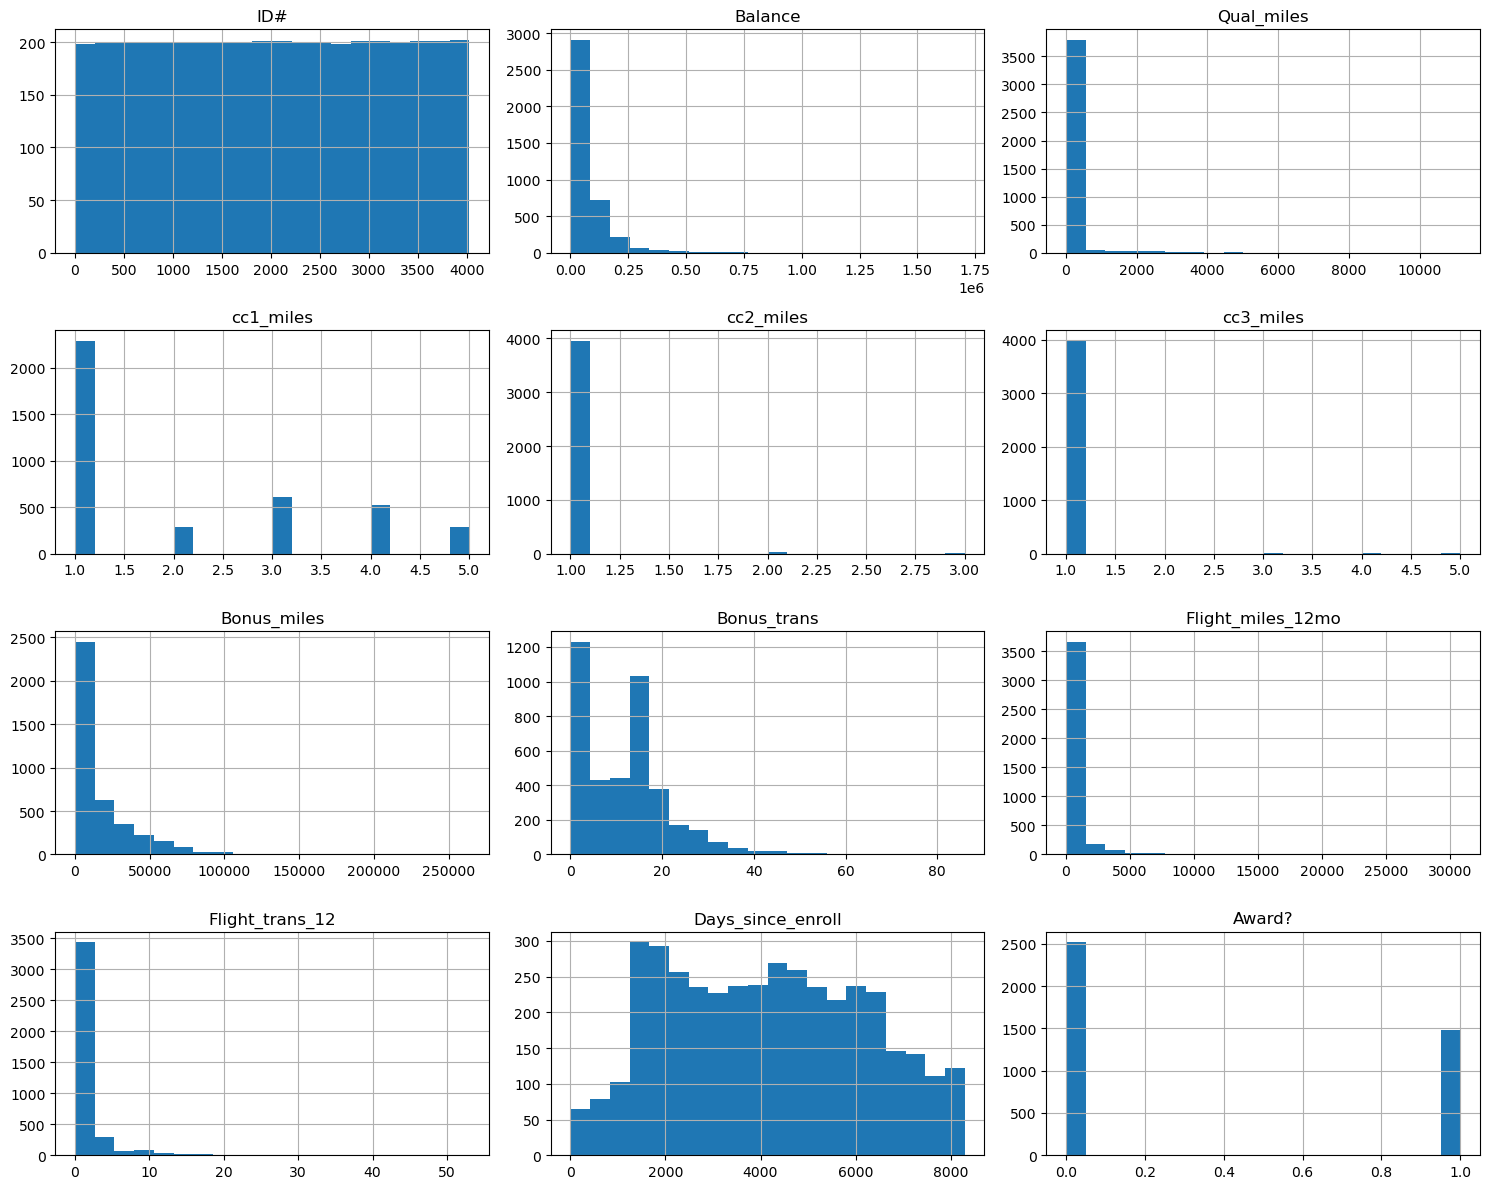

In [11]:
# Histograms
df.hist(figsize=(15, 12), bins=20)
plt.tight_layout()
plt.show()

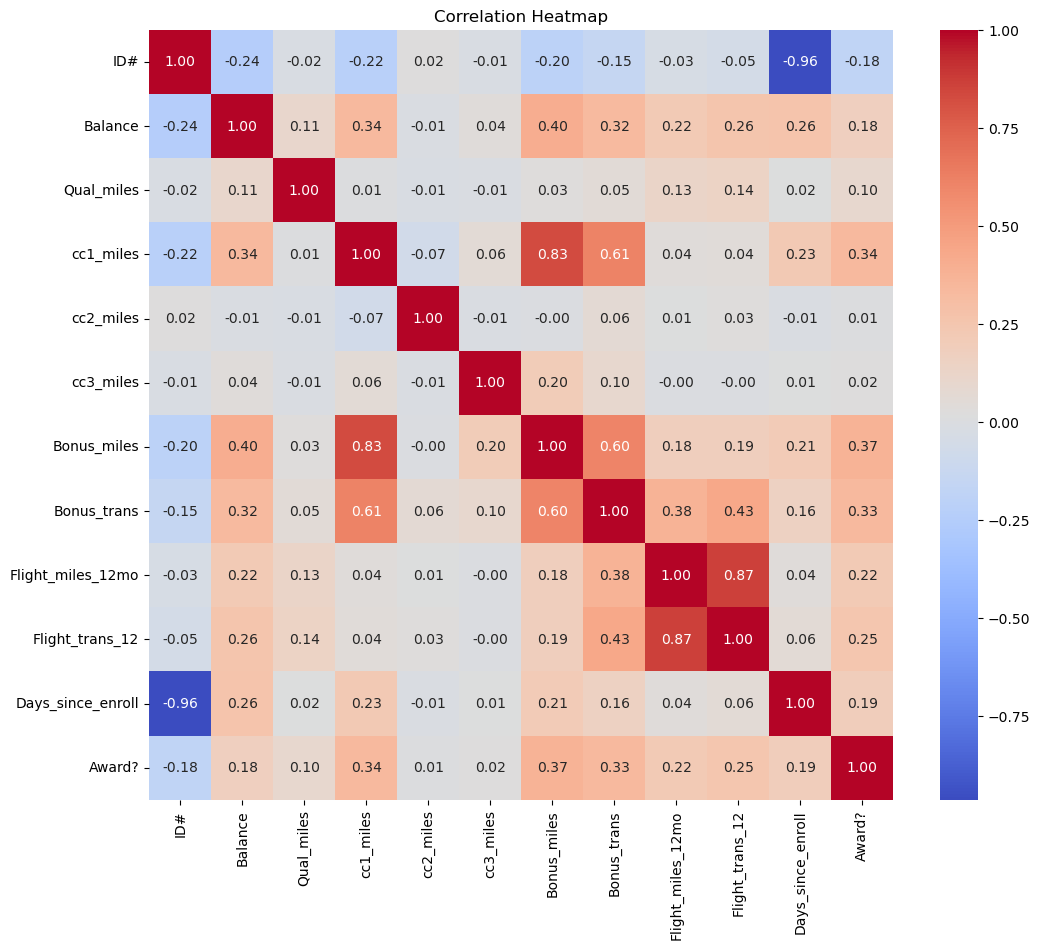

In [12]:
# Correlation Heatmaps
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

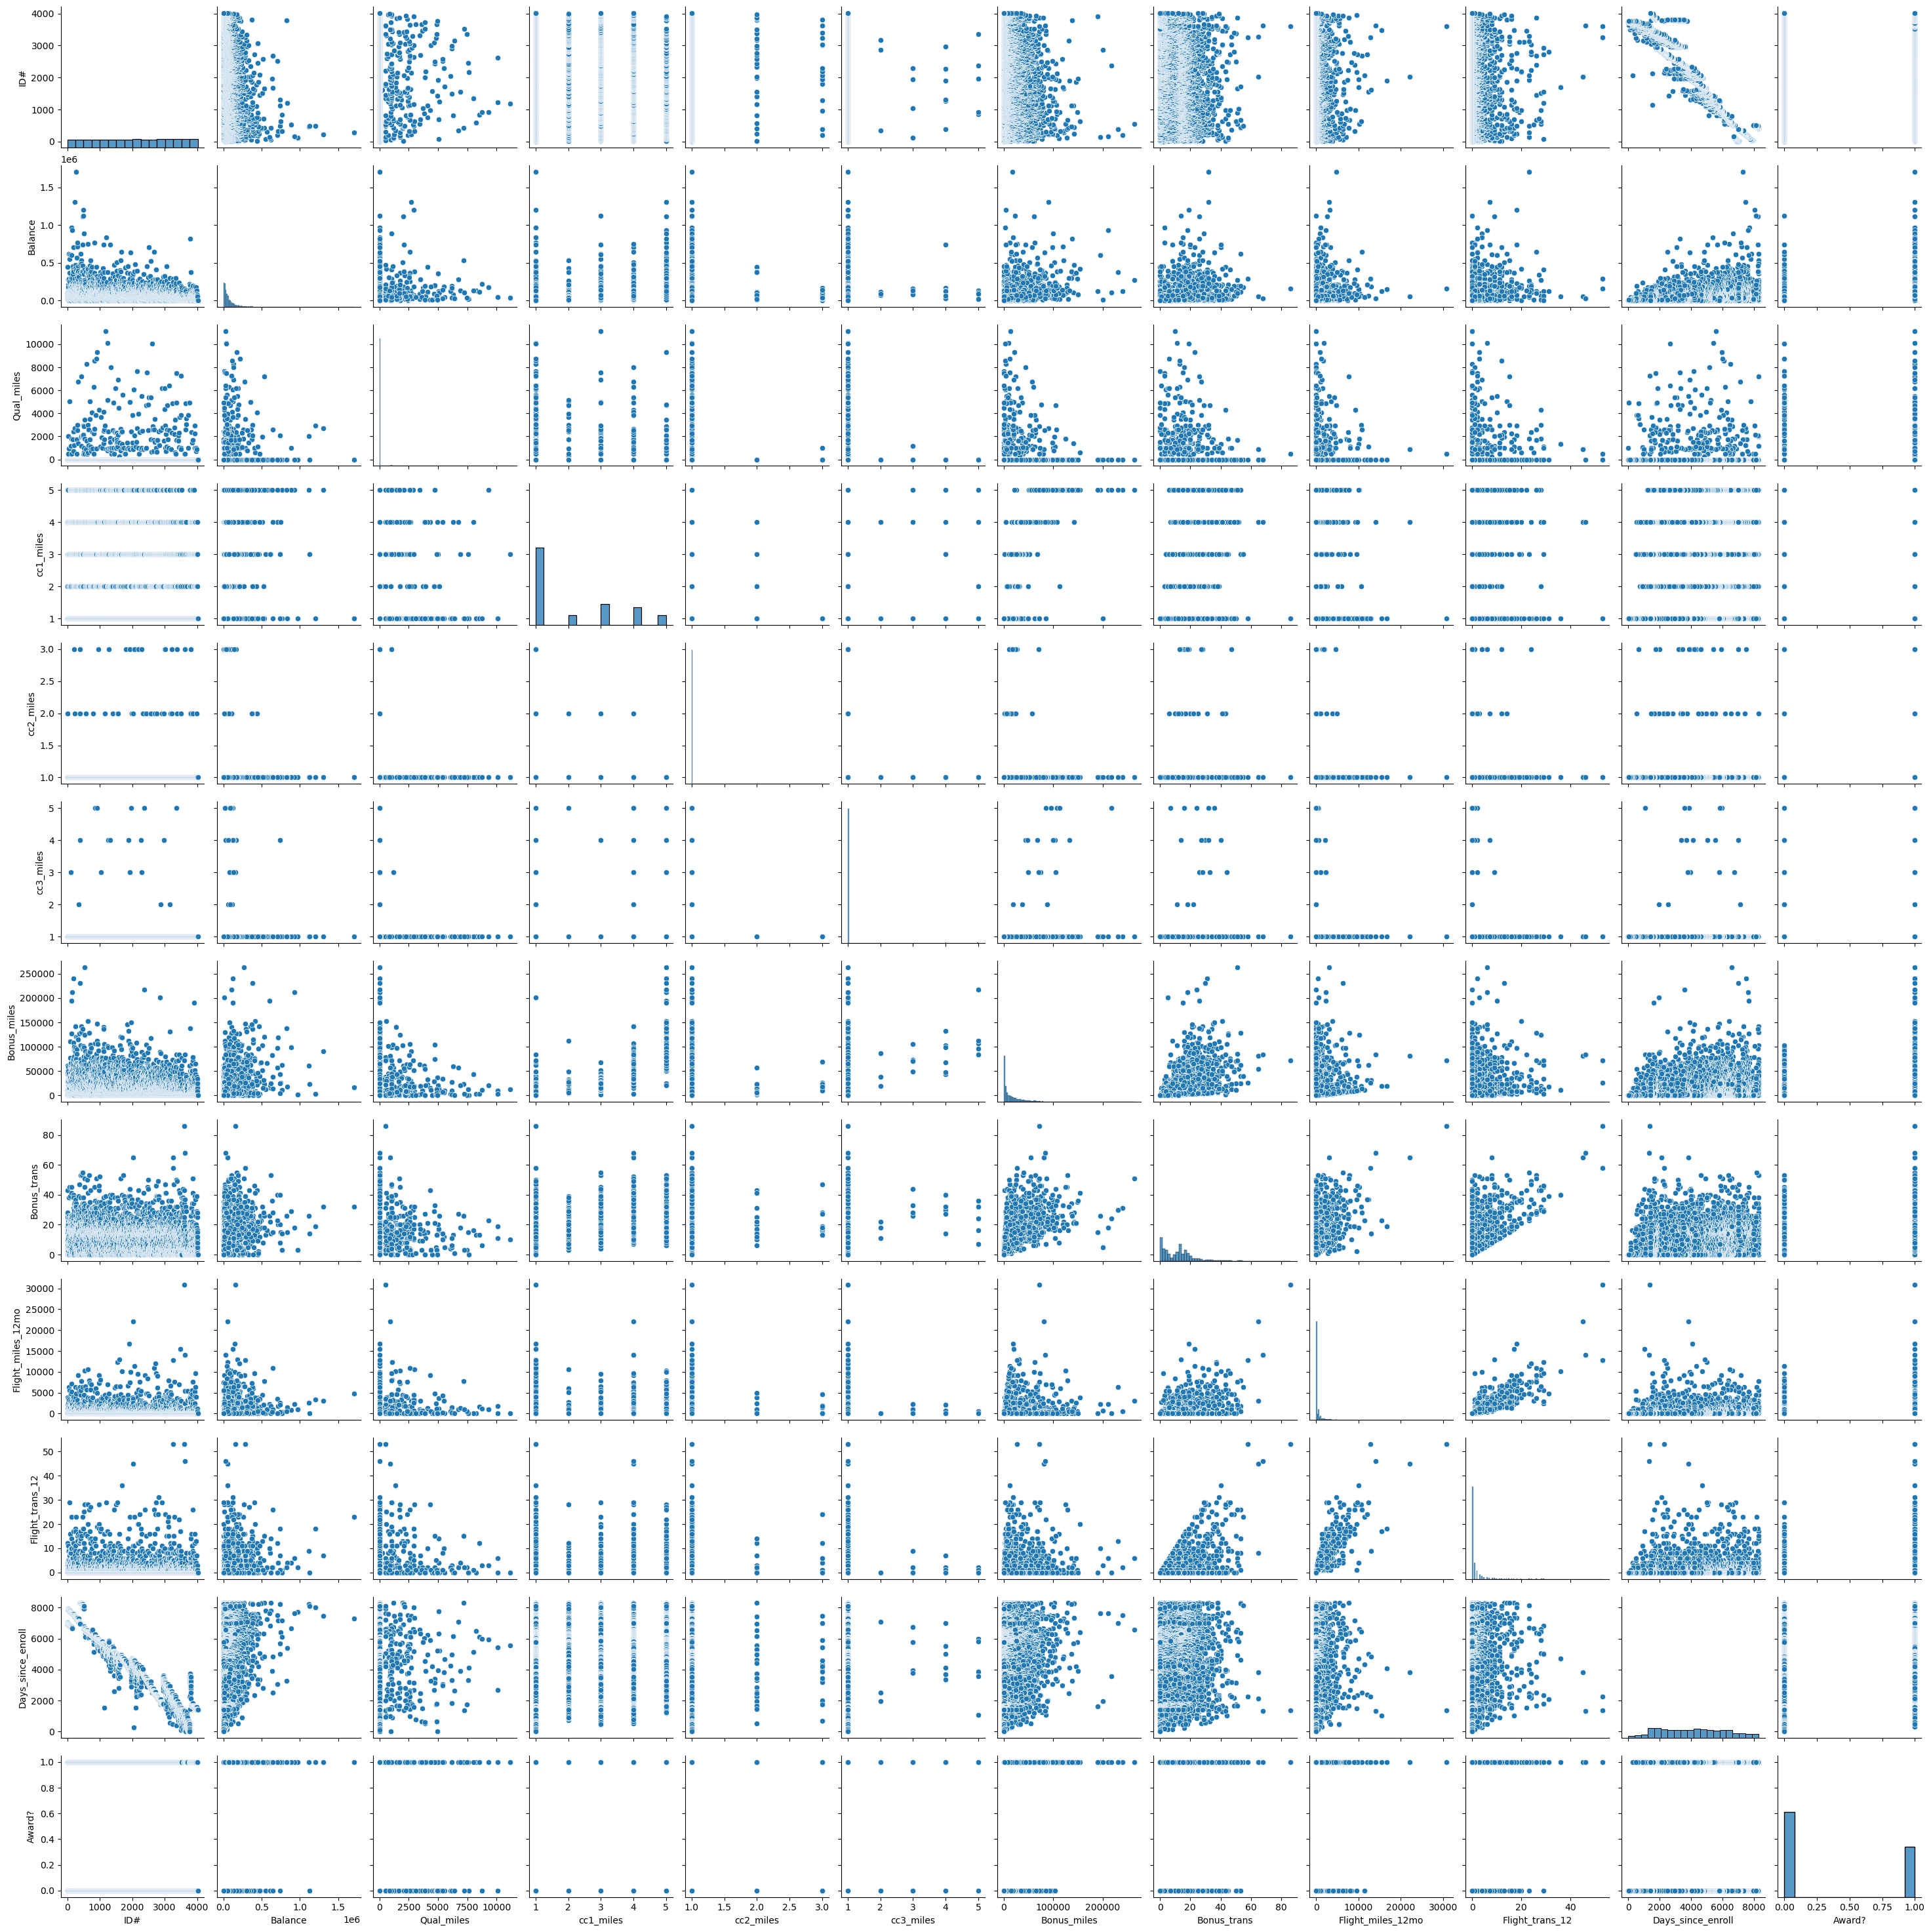

In [13]:
#pairplot
sns.pairplot(df)
plt.show()

In [14]:
#### Standardize Features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (3999, 12)


### Task 2

#### Cluster Analysis 

In [15]:
from sklearn.cluster import KMeans, DBSCAN
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

In [16]:
inertia = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

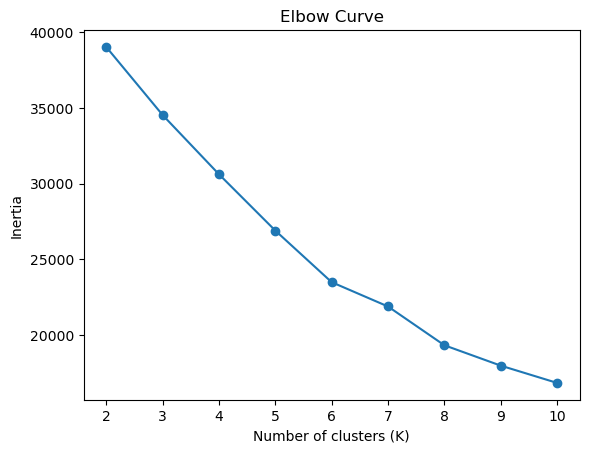

In [17]:
plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Curve")
plt.show()

In [22]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

print("K-Means Silhouette Score:", silhouette_score(X_scaled, kmeans_labels))

K-Means Silhouette Score: 0.2812008913802934


In [20]:
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

In [21]:
if n_clusters >= 2:
    print("DBSCAN Silhouette Score:",silhouette_score(X_scaled, dbscan_labels))
else:
    print("DBSCAN did not produce enough clusters.")

DBSCAN Silhouette Score: -0.2823258834687895


#### K-Means Insights

##### • K-Means grouped airline customers into different clusters based on similar travel patterns.

##### • Customers within the same cluster have similar mileage, flight frequency, and award usage.

##### • The Elbow Method helped determine an appropriate number of clusters, and the silhouette score indicates good clustering quality.

#### DBSCAN Insights

##### • DBSCAN identified dense groups of customers and detected outliers as noise.

##### • It is useful for finding clusters with irregular shapes and identifying unusual customer records.

##### • The clustering quality depends on the selected values of epsilon (eps) and minimum samples (min_samples).

##### conclusion : K-Means and DBSCAN were successfully implemented on the EastWest Airlines dataset. The data was preprocessed, scaled, and analyzed using clustering techniques. K-Means produced well-defined customer groups, while DBSCAN effectively detected outliers. The silhouette score was used to evaluate clustering quality, and both algorithms provided meaningful insights into customer segmentation.